# Sailing Challenge — Environment Walkthrough

This notebook introduces you to the sailing environment: how the boat moves, how wind works, what your agent observes, and how it is evaluated. By the end, you'll understand everything you need to start building your agent.

## 1. Setup

In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

sys.path.append(os.path.abspath('../src'))
sys.path.append(os.path.abspath('..'))

from env_sailing import SailingEnv
from sailing_physics import generate_velocity_polar_plot, generate_efficiency_curve, show_tacking_maneuver
from wind_scenarios import get_wind_scenario, WIND_SCENARIOS

## 2. Environment Overview

The sailing environment simulates a boat navigating from a starting point to a goal while being affected by wind. This is a challenging control problem because:

1. The boat can't move directly against the wind (upwind sailing requires strategic navigation)
2. Wind conditions change over time and vary across the space
3. Boat physics include momentum and sailing efficiency based on wind angle
4. Optimal routes often involve avoiding obstacles

Let's start by creating a basic environment and visualizing it:

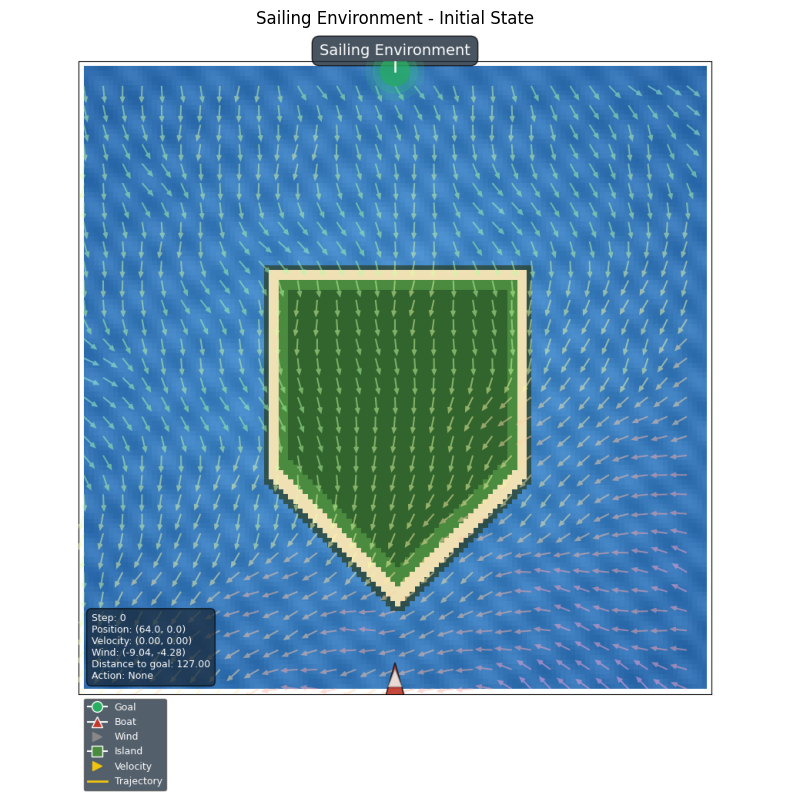

Environment Information:
Grid Size: (128, 128)
Starting Position: [64  0]
Goal Position: [ 64 127]
Initial Wind at Boat: [-9.03673104 -4.28222981]


In [2]:
# Create a basic sailing environment
env = SailingEnv(
    wind_grid_density=32,  # How many wind arrows to display
    wind_arrow_scale=360,  # Scale factor for arrow visualization
    render_mode="rgb_array"  # Generate images for visualization
)

# Reset the environment to initialize
observation, info = env.reset(seed=42)  # Fixed seed for reproducibility

# Render the environment
plt.figure(figsize=(10, 10))
plt.imshow(env.render())
plt.axis('off')
plt.title('Sailing Environment - Initial State')
plt.show()

# Describe the environment
print("Environment Information:")
print(f"Grid Size: {env.grid_size}")
print(f"Starting Position: {info['position']}")
print(f"Goal Position: {env.goal_position}")
print(f"Initial Wind at Boat: {info['wind']}")

### Understanding the Visualization

In the visualization above:

- **Boat**: The triangular shape represents your sailing boat. The pointed end indicates the direction.
- **Wind Arrows**: The white arrows show wind direction and strength at different points in the grid.
- **Goal**: The green circle at the top center is your destination.
- **Ocean**: The blue background represents the sailing area.
- **Island**: The sand-colored shape is an obstacle. More on that later.

The challenge is to navigate the boat from the starting position (bottom center) to the goal (top center) by choosing appropriate sailing directions that account for the wind.

### Wind Scenarios

The wind field you see is generated based on parameters defined during environment creation. In the challenge, you'll encounter several different initial wind fields:

1. **Training Wind Scenarios** (3 scenarios): Provided in the repository for you to develop and test your agent locally.
2. **Test Wind Scenario**: A hidden scenario used for final evaluation — accessible **only via Codabench submission**.

Each wind scenario has unique base wind directions across the map, BUT they all *evolve over time according to the same underlying dynamics* (i.e. they obey the same underlying Markov Decision Process). This means that regardless of which wind scenario you face, the wind will follow the same evolution rules as time progresses within an episode. Think of the wind scenarios as different starting points, but with consistent physics governing how they change.

The predefined training wind scenarios are available in the `wind_scenarios` module and can be loaded using the `get_wind_scenario()` function. We'll explore them later in this notebook.

## 3. Sailing Physics: How Wind Affects Movement

Sailing involves a fascinating interplay of physics. Unlike motorboats that can go in any direction, sailboats are constrained by their relation to the wind. Let's explore how sailing efficiency varies depending on the angle to the wind:

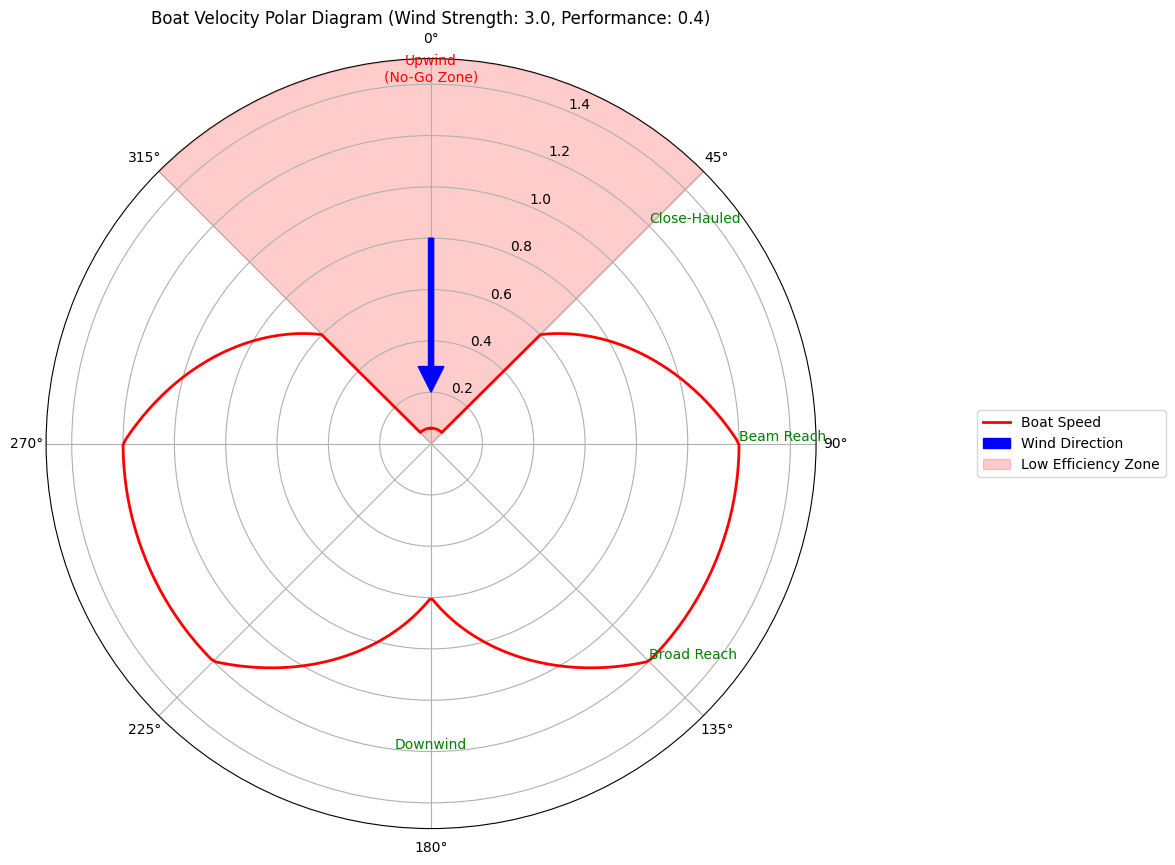

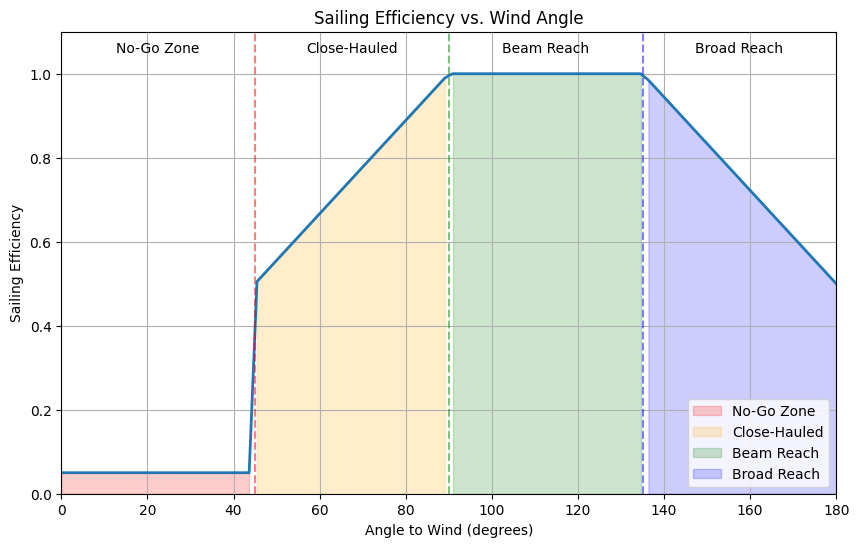

Key Sailing Concepts:
1. No-Go Zone: You cannot sail directly into the wind (within ~45° of upwind)
2. Close-hauled: Sailing at ~45° to the wind - relatively efficient but not optimal
3. Beam Reach: Sailing perpendicular to the wind - typically the fastest point of sail
4. Broad Reach: Wind coming from behind at an angle - also very efficient
5. Running: Wind directly behind - surprisingly not the fastest due to aerodynamics


In [3]:
# Create a polar plot showing sailing efficiency by angle
polar_fig = generate_velocity_polar_plot(wind_strength=3.0, boat_performance=0.4)
plt.show()

# Create an efficiency curve
eff_fig = generate_efficiency_curve()
plt.show()

print("Key Sailing Concepts:")
print("1. No-Go Zone: You cannot sail directly into the wind (within ~45° of upwind)")
print("2. Close-hauled: Sailing at ~45° to the wind - relatively efficient but not optimal")
print("3. Beam Reach: Sailing perpendicular to the wind - typically the fastest point of sail")
print("4. Broad Reach: Wind coming from behind at an angle - also very efficient")
print("5. Running: Wind directly behind - surprisingly not the fastest due to aerodynamics")

## 4. Actions and Control Mechanics

In the sailing environment, your agent needs to choose from a discrete set of actions to navigate the boat. Let's understand the action space and how it affects the boat's movement.

### Action Space

There are 9 possible actions your agent can take:
- Actions 0-7: Move in one of 8 directions (like compass points)
- Action 8: Stay in place

These actions represent the direction you want the boat to move, but the actual movement will be influenced by:
- Wind direction and strength
- Sailing efficiency at that angle to the wind
- Current velocity (momentum)
- Physical constraints of sailing

Let's see how these actions correspond to directions:

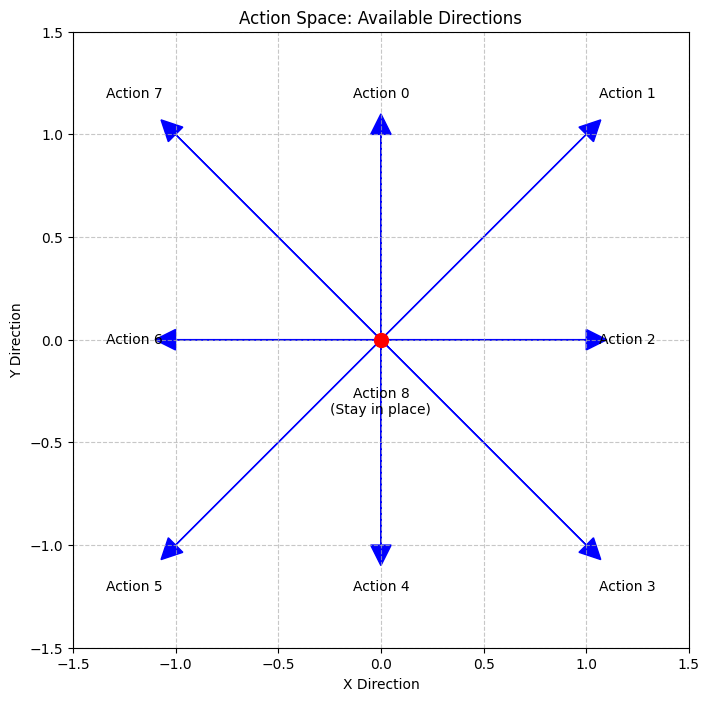

Important Note: The actual movement resulting from each action will depend on wind conditions!
- Trying to move directly upwind (against the wind) will result in minimal progress
- Moving perpendicular to the wind (beam reach) will be most efficient
- Your agent needs to learn which actions are effective in different wind conditions


In [ ]:
# Define the action space
actions = [
    (0, 1),    # 0: North
    (1, 1),    # 1: Northeast
    (1, 0),    # 2: East
    (1, -1),   # 3: Southeast
    (0, -1),   # 4: South
    (-1, -1),  # 5: Southwest
    (-1, 0),   # 6: West
    (-1, 1),   # 7: Northwest
    (0, 0)     # 8: Stay in place
]

# Create a visual representation of the action space
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)

# Draw arrows for each direction
for i, (dx, dy) in enumerate(actions[:8]):  # Skip the "stay in place" action
    ax.arrow(0, 0, dx, dy, head_width=0.1, head_length=0.1, fc='blue', ec='blue')
    ax.text(dx*1.2, dy*1.2, f"Action {i}", ha='center', va='center')

# Mark the center for "stay in place"
ax.plot(0, 0, 'ro', markersize=10)
ax.text(0, -0.3, "Action 8\n(Stay in place)", ha='center', va='center')

# Add grid, title and labels
ax.grid(True, linestyle='--', alpha=0.7)
ax.set_title('Action Space: Available Directions')
ax.set_xlabel('X Direction')
ax.set_ylabel('Y Direction')
ax.set_aspect('equal')
plt.show()

print("Important Note: The actual movement resulting from each action will depend on wind conditions!")
print("- Trying to move directly upwind (against the wind) will result in minimal progress")
print("- Moving perpendicular to the wind (beam reach) will be most efficient")
print("- Your agent needs to learn which actions are effective in different wind conditions")

## 5. Observation and State Space

Your agent will make decisions based on observations from the environment. Let's understand what information is available to your agent at each step.

### Observation Structure

The observation is a single flat vector containing:
- `x, y`: Current position (indices 0, 1)
- `vx, vy`: Current velocity (indices 2, 3)
- `wx, wy`: Current wind vector at the boat's position (indices 4, 5)
- **Full Wind Field**: The complete 128x128x2 wind field, flattened (indices 6 to 6+32767)
- **World Map**: The 128x128 binary grid indicating water (0) vs island (1), flattened (indices 6+32768 onward)

The full wind field gives your agent "weather information" across the entire environment. The world map tells your agent where the island is. Together, these allow strategic route planning — similar to how real sailors use weather forecasts and nautical charts.

Let's examine a sample observation:

Observation shape: (49158,)

Observation breakdown:
  [0:2]   Position (x, y): (64.0, 0.0)
  [2:4]   Velocity (vx, vy): (0.000, 0.000)
  [4:6]   Wind at position (wx, wy): (-9.037, -4.282)
  [6:32774]  Wind field (128x128x2 = 32768 values)
  [32774:49158] World map (128x128 = 16384 values)

World map: 2955 island cells out of 16384 total


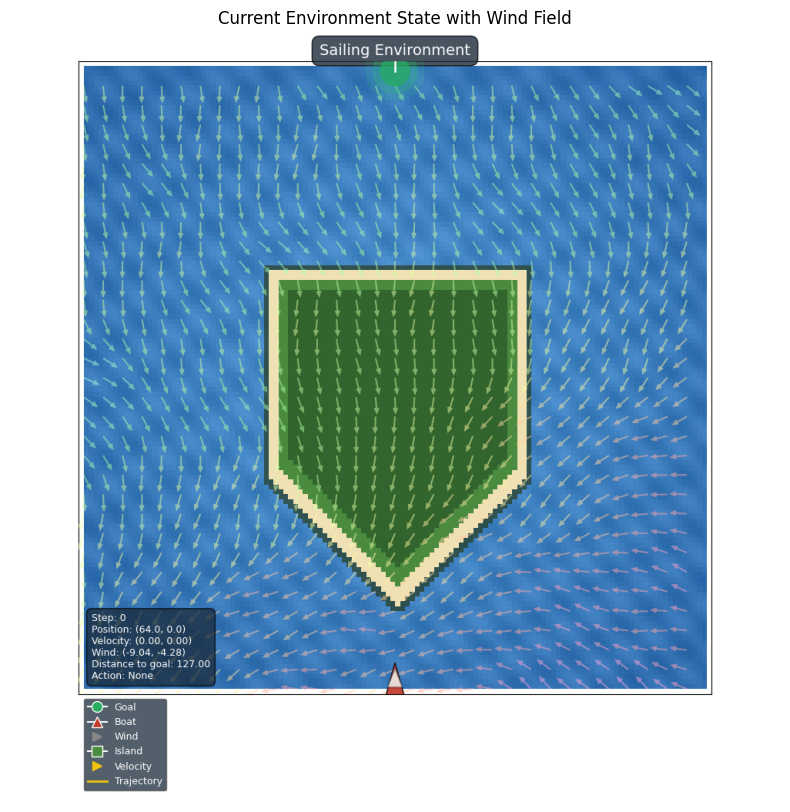

In [5]:
# Reset the environment
observation, info = env.reset(seed=42)

# Display the observation structure
grid_size = env.grid_size
wind_field_size = grid_size[0] * grid_size[1] * 2
world_map_size = grid_size[0] * grid_size[1]

print(f"Observation shape: {observation.shape}")
print(f"\nObservation breakdown:")
print(f"  [0:2]   Position (x, y): ({observation[0]:.1f}, {observation[1]:.1f})")
print(f"  [2:4]   Velocity (vx, vy): ({observation[2]:.3f}, {observation[3]:.3f})")
print(f"  [4:6]   Wind at position (wx, wy): ({observation[4]:.3f}, {observation[5]:.3f})")
print(f"  [6:{6+wind_field_size}]  Wind field ({grid_size[0]}x{grid_size[1]}x2 = {wind_field_size} values)")
print(f"  [{6+wind_field_size}:{6+wind_field_size+world_map_size}] World map ({grid_size[0]}x{grid_size[1]} = {world_map_size} values)")

# Show the world map (island detection)
world_map = observation[6+wind_field_size:].reshape(grid_size[1], grid_size[0])
print(f"\nWorld map: {int(world_map.sum())} island cells out of {world_map_size} total")

# Visualize the current state
plt.figure(figsize=(10, 10))
plt.imshow(env.render())
plt.axis('off')
plt.title('Current Environment State with Wind Field')
plt.show()

### Visualizing Environment State from Observations

The `SailingEnv.visualize_observation()` function allows you to create a complete visualization of the environment from any observation. This is particularly useful for:

1. **Understanding the current state** of the sailing environment
2. **Debugging agent behavior** by visualizing key decision points
3. **Analyzing wind patterns** across the entire grid

This visualization includes the boat position, velocity, wind field, and goal location in a format identical to the environment's built-in render method.

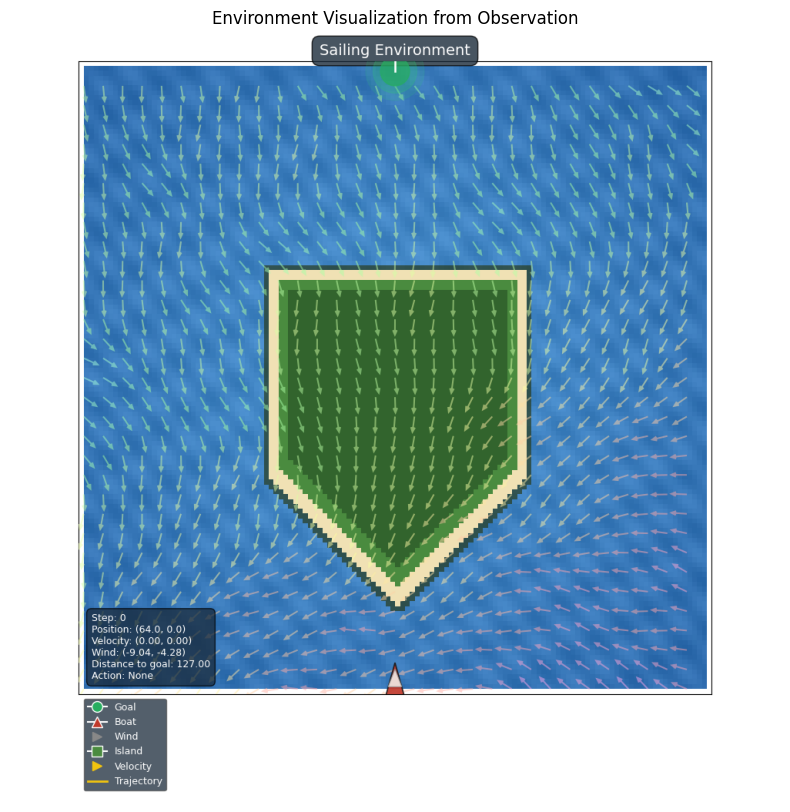

In [6]:
# Visualize the observation as an image
plt.figure(figsize=(10, 10))
img = SailingEnv.visualize_observation(observation)  # Call as a class method
plt.imshow(img)
plt.axis('off')
plt.title('Environment Visualization from Observation')
plt.show()

## 6. Rewards and Goal

Now let's understand how success is measured in the sailing environment.

### Reward Structure

The sailing environment provides rewards as follows:

- **Reaching the goal**: Large positive reward (100.0)
- **Other steps**: No reward (0.0)

This is a sparse reward structure, which makes the problem challenging. Your agent only receives feedback when it successfully reaches the goal.

### Discounted Reward

In reinforcement learning, we often use **discounted rewards** to emphasize immediate rewards over future ones. The discounted reward is calculated as:

$$R_{discounted} = \sum_{t=0}^{T} \gamma^t r_t$$

Where:
- $r_t$ is the reward at time step $t$
- $\gamma$ is the discount factor ($\gamma=0.995$ in our environment)
- $T$ is the total number of time steps

This means reaching the goal quickly results in a higher discounted reward than reaching it slowly.

### Episode Termination

An episode ends when any of these occur:

1. The agent **reaches the goal** (success — reward 100)
2. The boat **crashes into the island** (immediate termination — reward 0)
3. The **maximum horizon** (500 steps) is reached without reaching the goal (reward 0)

Let's run a simple example — a naive agent that always goes North. Watch what happens:

In [7]:
# Reset the environment
observation, info = env.reset(seed=42)
discount_factor = 0.995

# Demo: a naive agent that always goes North
# On this grid, going straight North runs into the island!
print("Demo: always choosing action 0 (North)...\n")

prev_pos = None
for step in range(1, 100):
    observation, reward, terminated, truncated, info = env.step(0)
    pos = tuple(info['position'])

    if prev_pos is not None and pos == prev_pos and not env.is_stuck:
        pass  # boat is just slow
    elif env.is_stuck and prev_pos != pos:
        print(f"Step {step}: Crashed into the island at position {info['position']}!")
        print("  -> Episode terminates immediately. Reward = 0.\n")
    elif env.is_stuck:
        pass  # already reported
    elif step <= 30 and step % 5 == 0:
        print(f"Step {step}: Position {info['position']}")

    prev_pos = pos

    if terminated or truncated:
        break

# Show discounted reward comparison
print("Discounted reward examples (if goal IS reached):")
print(f"  Discount factor: {discount_factor}")
for steps in [30, 50, 100, 200, 500]:
    dr = 100 * (discount_factor ** (steps - 1))
    print(f"  Reaching goal in {steps:>3d} steps -> discounted reward = {dr:.2f}")
print(f"\nKey takeaway: reaching the goal faster = higher reward.")
print(f"Crashing into the island = stuck forever = reward 0.")

Demo: always choosing action 0 (North)...

Step 5: Position [64 10]
Step 8: Crashed into the island at position [64 18]!
  -> Episode terminates immediately. Reward = 0.

Discounted reward examples (if goal IS reached):
  Discount factor: 0.995
  Reaching goal in  30 steps -> discounted reward = 86.47
  Reaching goal in  50 steps -> discounted reward = 78.22
  Reaching goal in 100 steps -> discounted reward = 60.88
  Reaching goal in 200 steps -> discounted reward = 36.88
  Reaching goal in 500 steps -> discounted reward = 8.20

Key takeaway: reaching the goal faster = higher reward.
Crashing into the island = stuck forever = reward 0.


## 7. The Island

You saw the sand-colored shape in the environment — and the demo above showed what happens when the boat runs into it. The island is a composite shape: a **rectangle** in the upper portion with a **triangular prow** extending south toward the starting position.

### Crash behavior

* When the boat's position lands on an island cell, it **crashes** and the **episode terminates immediately** with reward 0.
* There is no recovery — crashing is a hard failure.

### Detecting the island

The observation includes a **world map** — a 128x128 binary grid where `0 = water` and `1 = island`. Your agent can use this to plan routes that avoid the island. Here's how to extract it:

### Visual note

Sometimes in the visualization you might see an agent appear to travel along the border of the island without getting stuck. This is a rendering artifact — the actual position (shown in the info text) still maps to a water cell.

In [ ]:
########## In the act(self, observation) function of your agent:
# position = np.array([observation[0], observation[1]])
# x, y = position.astype(np.int32)
# world_map = observation[6 + 128*128*2:]
# island_grid = world_map.reshape((128, 128))
# if island_grid[y, x] == 1:
#     print('Island!')
# else:
#     print('Water')

**Notice that the order of indexing is y then x.** This is because 2d grids are first indexed by rows and then cols.


Note: this is true for the windfield as well (pro-tip: you can use the same reshape code to get the windfield at different positions).

w_x and w_y, the windfield at the current pos are in the 'regular' order (x then y) thanks to a helper

In [ ]:
###   The helper
#     def _get_wind_at_position(self, position):
#        """Get wind vector at given position."""
#        x, y = position
#        #Numpy arrays are indexed with [y, x] order
#        return self.wind_field[int(y), int(x)]

## A Baseline That Reaches the Goal: SuperNaiveAgent

The "always go North" demo crashed into the island. Let's now see the `SuperNaiveAgent`, a simple heuristic that avoids the island by following the grid borders. It always reaches the goal — but slowly, because it ignores the wind entirely:

In [8]:
from src.agents.agent_super_naive import SuperNaiveAgent

baseline_agent = SuperNaiveAgent()
baseline_agent.seed(42)

observation, info = env.reset(seed=42)
baseline_agent.reset()

discount_factor = 0.995
total_reward = 0
for step in range(1, 501):
    action = baseline_agent.act(observation)
    observation, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    if step % 50 == 0:
        print(f"Step {step}: Position {info['position']}, Dist to goal: {info['distance_to_goal']:.1f}")
    if terminated:
        discounted = 100 * (discount_factor ** (step - 1))
        print(f"\nGoal reached at step {step}!")
        print(f"Discounted reward: {discounted:.2f}")
        break
    if truncated:
        print(f"\nEpisode ended at step {step} without reaching the goal.")
        break

if not (terminated or truncated):
    print("Episode did not finish within 1000 steps.")

Step 50: Position [0 0], Dist to goal: 142.2
Step 100: Position [0 0], Dist to goal: 142.2
Step 150: Position [0 2], Dist to goal: 140.4
Step 200: Position [  0 125], Dist to goal: 64.0

Goal reached at step 230!
Discounted reward: 31.73


## 8. Wind Scenarios

As mentioned earlier, the sailing challenge includes different wind conditions that your agent will need to handle. Let's load and visualize each of the training wind scenarios to understand their unique characteristics.

### Training Wind Scenarios

The training wind scenarios are designed to expose your agent to different starting wind patterns:

- Each wind scenario has a unique starting configuration (wind pattern)
- All windfields evolve over time according to the same underlying dynamics
- Your agent must learn to adapt to both the initial conditions and how they change during an episode

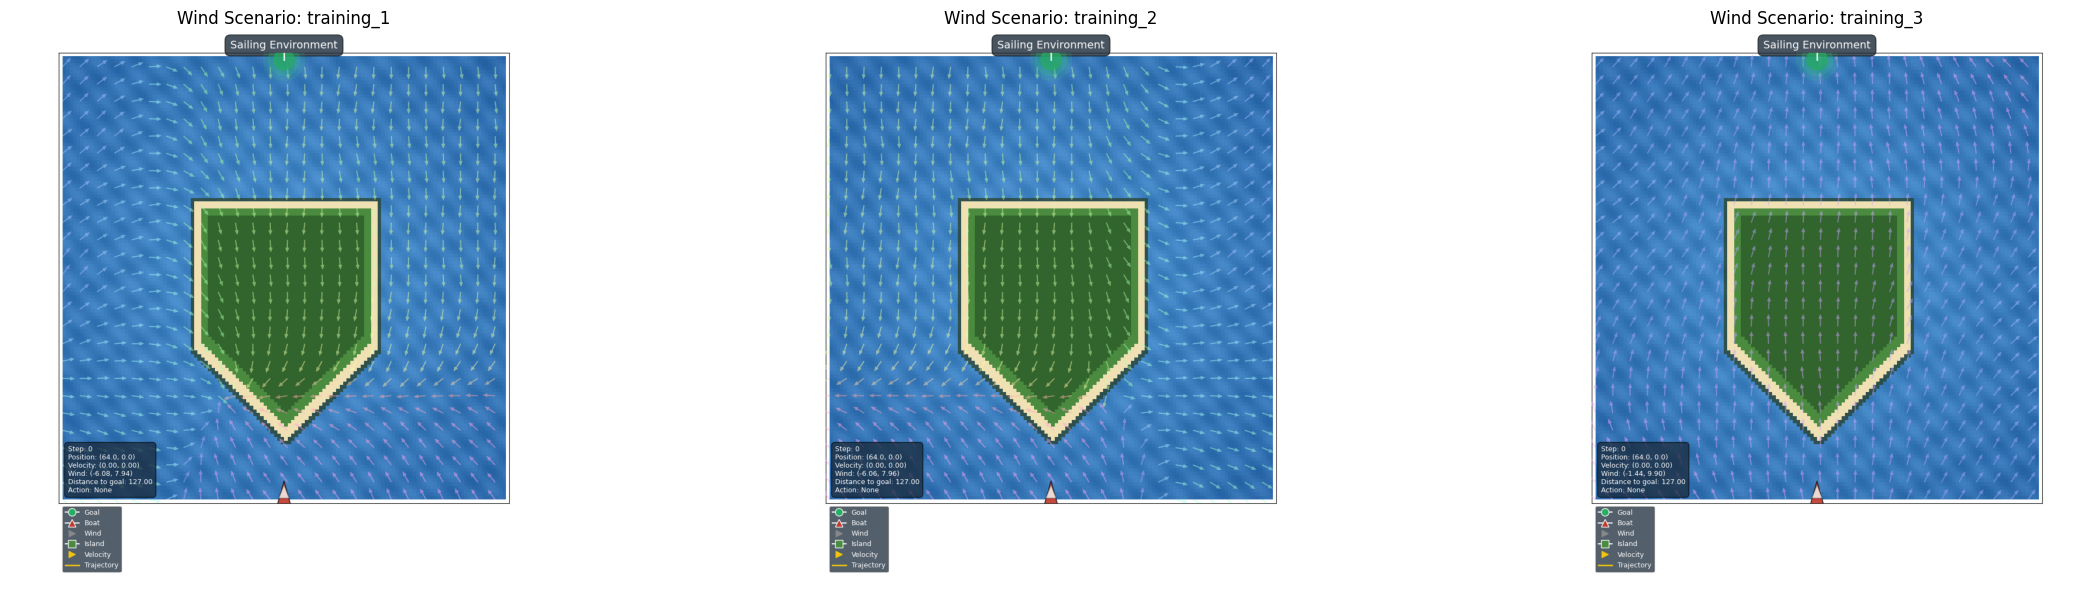

In [9]:
# Load each wind scenario and visualize its wind pattern
wind_scenarios = {
    "training_1": get_wind_scenario("training_1"),
    "training_2": get_wind_scenario("training_2"),
    "training_3": get_wind_scenario("training_3"),
}

# Create a figure for each wind scenario
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

for i, (name, windfield) in enumerate(wind_scenarios.items()):
    viz_windfield = windfield.copy()
    
    # Create environment with this wind scenario
    env = SailingEnv(
        wind_init_params=viz_windfield['wind_init_params'],
        wind_evol_params=viz_windfield['wind_evol_params'],
        wind_grid_density=25,
        wind_arrow_scale=360,
        render_mode="rgb_array"
    )
    
    # Reset and render
    env.reset(seed=42)
    
    # Display the image
    axes[i].imshow(env.render())
    axes[i].set_title(f"Wind Scenario: {name}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()


## 9. Wind Evolution

The wind doesn't remain static during an episode - it evolves over time according to common evolution parameters (which define an underlying common Markov Decision Process) shared by all wind scenarios. Let's visualize how wind changes over time in an wind scenario using an interactive slider:

In [10]:
# Create an environment with the first training wind scenario
wind_scenario = get_wind_scenario("training_1")

env = SailingEnv(
    wind_init_params=wind_scenario['wind_init_params'],
    wind_evol_params=wind_scenario['wind_evol_params'],
    wind_grid_density=25,
    wind_arrow_scale=360,
    render_mode="rgb_array"
)

# Reset the environment
env.reset(seed=42)

# Capture wind evolution over many steps for interactive visualization
wind_frames = []
for step in range(50):  # Capture 50 frames for smooth animation
    # Render current state
    frame = env.render()
    wind_frames.append(frame)
    
    # Take a "stay in place" action to let wind evolve
    env.step(8)  # Action 8 is "stay in place"

# Create interactive slider visualization
from ipywidgets import interact, IntSlider
import matplotlib.pyplot as plt

def show_wind_evolution(step):
    """Display wind evolution at a specific step."""
    plt.figure(figsize=(10, 10))
    plt.imshow(wind_frames[step])
    plt.axis('off')
    plt.title(f'Wind Evolution - Step {step}')
    plt.show()

# Create interactive slider
interact(
    show_wind_evolution,
    step=IntSlider(
        min=0,
        max=len(wind_frames)-1,
        step=1,
        value=0,
        description='Step:',
        style={'description_width': 'initial'}
    )
)

print("Use the slider above to explore how the wind pattern changes over time!")
print("- Wind direction and strength evolve according to the common evolution parameters")
print("- This evolution is the same for all training and test wind scenarios")
print("- Your agent must adapt to these changing conditions while navigating")
print("- For debugging, you can create a static environment: SailingEnv(..., static_wind=True)")

interactive(children=(IntSlider(value=0, description='Step:', max=49, style=SliderStyle(description_width='ini…

Use the slider above to explore how the wind pattern changes over time!
- Wind direction and strength evolve according to the common evolution parameters
- This evolution is the same for all training and test wind scenarios
- Your agent must adapt to these changing conditions while navigating
- For debugging, you can create a static environment: SailingEnv(..., static_wind=True)


## 10. Conclusion and Next Steps

You now have a solid understanding of the sailing environment:

- The physics of sailing and how wind angle affects efficiency
- The action space (9 discrete directions) and control mechanics
- The observation space: position, velocity, local wind, full wind field, and world map (island)
- The reward structure (sparse: 100 on goal, 0 otherwise) and discounting
- The island obstacle and how to detect it
- The 3 training wind scenarios and how wind evolves over time

### Next Steps

1. **`design_agent.ipynb`**: Learn how to build your sailing agent
2. **`validate_agent.ipynb`**: Check that your agent meets the submission interface
3. **`evaluate_agent.ipynb`**: Measure your agent's performance across training scenarios
4. **`visualize_agent.ipynb`**: Watch your agent navigate and debug its behavior

The key challenge is **generalization**: your agent must perform well not only on the 3 training wind scenarios (available locally) but also on a hidden test scenario accessible **only via Codabench submission**. All scenarios share the same wind evolution dynamics — only the initial wind patterns differ.